ROUNDING IS APPLIED IN LEANNE'S SCRIPT:  
/scratch/hydro5/users/la17355/FUTURE-FLOOD/UKCP_soil_moisture/volumetric_30m/soil_depth_missing_tests/

## ------------------------------------------------------------ ###
## Set up environment
## ------------------------------------------------------------ ###

In [2]:
import glob
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import rioxarray  # noqa: F401  (registers .rio accessor)
import xarray as xr
import matplotlib.pyplot as plt
from rasterio.warp import Resampling, reproject
from shapely.geometry import box
import math

# --------------------------
# Configuration — edit these
# --------------------------
CRS_TARGET = "EPSG:27700"

DEM_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem/"
CSV_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/"
NETCDF_DIR = "/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/"
SOIL_TEXTURE_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
POROSITY_CSV = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/SoilTexture/USDA_soil_texture_effective_porosity.csv"
SOILS_LOOKUP_CSV = "../../Data/Rawls_soil_lookup.csv"  # USDA_soil, Hydraulic_conductivity

from functions import filter_closer_to_catchment_xr_bounds
from helper_functions import *

from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS, OUT_DIR
event_details_fp = 'EventDetails'

## ------------------------------------------------------------ ###
## Loop through all catchments
## ------------------------------------------------------------ ###

In [13]:
print(len(list(CATCHMENT_LOOKUP_DICT.keys())))
# for TARGET_HA in list(CATCHMENT_LOOKUP_DICT.keys()):
for TARGET_HA in list(['23']):
    
    outpath = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/{event_details_fp}/Catchment_{TARGET_HA}/all_events_added_soilvars_withbias.csv"
    if not os.path.isfile(outpath):
        print(TARGET_HA, ": Already exists")
        pass
    else:
        print(TARGET_HA, "doesn't exist")
        
        # Get boundary data
        boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(TARGET_HA)]
        CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
        
        # Get catchment data
        catchment_name = CATCHMENT_LOOKUP_DICT[TARGET_HA]
        combined_fp_new = os.path.join(OUT_DIR, f"Catchment_{TARGET_HA}", f"{catchment_name}_new.pkl")
        events_this_catchment = pd.read_pickle(combined_fp_new)
        
        ##############################################
        ### Load static variables for catchment
        # - DEM (not sure why)
        # - Porosity
        # - Lu (effective depth)
        ##############################################

        # --------------------------
        # 1. Load DEM for the target catchment
        # --------------------------
        dem_files = [p for p in glob.glob(os.path.join(DEM_DIR, "*.tif"))
            if extract_ha_num(p) in [TARGET_HA]]
        if not dem_files:
            raise FileNotFoundError(f"No DEM found for HA_NUM {TARGET_HA} in {DEM_DIR}")

        dem_path = dem_files[0]
        ha_num = extract_ha_num(dem_path)

        with rasterio.open(dem_path) as dem:
            dem_info = {"bounds": box(*dem.bounds),"transform": dem.transform,"crs": dem.crs,"width": dem.width,
                        "height": dem.height,"mask": dem.read(1), }

        dem_mask_bool = dem_info["mask"] == -9999
        print(f"Loaded DEM for HA {ha_num}: {dem_info['width']}x{dem_info['height']}")

        # --------------------------
        # 2. Load static soil variables (porosity + Lu grids (aligned to the same soil-texture raster))
        # --------------------------
        soil_grids = load_soil_grids(POROSITY_CSV, SOILS_LOOKUP_CSV, SOIL_TEXTURE_DIR, [TARGET_HA])
        if ha_num not in soil_grids:
            raise KeyError(f"No soil-texture raster found for HA {ha_num}")

        lu_data = soil_grids[ha_num]["lu"]
        hc_data = soil_grids[ha_num]["hc"]
        porosity_data = soil_grids[ha_num]["porosity"]
        fumax_data = porosity_data * lu_data
        print(f"Porosity range: {np.nanmin(porosity_data):.3f} to {np.nanmax(porosity_data):.3f}")
        print(f"Lu range: {np.nanmin(lu_data):.3f} to {np.nanmax(lu_data):.3f} m")

        # --------------------------
        # 3. Aggregate static soil variables to 5 km (porosity + Lu grids (aligned to the same soil-texture raster))
        # --------------------------
        # Get one soil_moisture file for using to define shape 
        soil_moisture_5km_fp = '/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_10/r001i1p02242_20651201-20661130_mrso.nc'
        with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
            grav_clipped = filter_closer_to_catchment_xr_bounds(
                    soil_moisture_5km.isel(time=0), CATCHMENT_POLY)["moisture_content_of_soil_layer"]
            grav_clipped = grav_clipped.rio.write_crs("EPSG:27700")

        lu_5km = aggregate_to_coarse_grid(lu_data, dem_info, grav_clipped)
        lu_5km_da = grav_clipped.copy(data=lu_5km.reshape(np.squeeze(grav_clipped.values).shape))
        lu_5km_da.name = "lu_mean_5km"  

        hc_5km = aggregate_to_coarse_grid(hc_data, dem_info, grav_clipped)
        hc_5km_da = grav_clipped.copy(data=hc_5km.reshape(np.squeeze(grav_clipped.values).shape))
        hc_5km_da.name = "hc_mean_5km"      

        fumax_5km = aggregate_to_coarse_grid(fumax_data, dem_info, grav_clipped)
        fumax_5km_da = grav_clipped.copy(data=fumax_5km.reshape(np.squeeze(grav_clipped.values).shape))
        fumax_5km_da.name = "fumax_mean_5km"  

        porosity_5km = aggregate_to_coarse_grid(porosity_data, dem_info, grav_clipped)
        porosity_5km_da = grav_clipped.copy(data=porosity_5km.reshape(np.squeeze(grav_clipped.values).shape))
        porosity_5km_da.name = "porosity_mean_5km"              
        
        
        ##############################################
        ### MAIN
        ##############################################

        results_total = []
        skip_HA = False
        
        for ENSEMBLE_STR in ENSEMBLE_MEMBERS:
            ENSEMBLE_INT = int(ENSEMBLE_STR.lstrip('0'))
            ENSEMBLE = f"Ens_{ENSEMBLE_STR}"
            print(ENSEMBLE, ENSEMBLE_INT, ENSEMBLE_STR )

            # Get event data for this ensemble member
            csv_dir = '/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/'
            csv_path = csv_dir +  f'{catchment_name}_{ENSEMBLE_STR}_full_events_with_event_nums.csv'
            events_df = pd.read_csv(csv_path)
            # events_df = events_df[events_df['peaks']<130].copy()

            # Get processed event data
            events_this_catchment_this_ens = events_this_catchment[events_this_catchment['ens']==ENSEMBLE_STR].copy()
            print(len(events_df), len(events_this_catchment_this_ens))

            if not len(events_df) == len(events_this_catchment_this_ens):
                print("dataframes different lengths" )
                skip_HA = True
                break            
            
            events_this_catchment_this_ens = events_this_catchment_this_ens.merge(
                events_df[["event_num", "start_indices"]],
                on="event_num",how="left",)
            
#             events_this_catchment_this_ens = events_this_catchment_this_ens.merge(
#                 events_df[["event_num", "start_month", "start_day", "start_indices"]],
#                 on="event_num",how="left",)            

            # --------------------------
            # 4. Run the pipeline for each event, keeping intermediate arrays
            # --------------------------
            results = []

            for i, row in events_this_catchment_this_ens.iterrows():
                year, month, day = int(row["start_year"]), int(row["start_month"]), int(row["start_day"])
                event_num = int(row["event_num"])
                start_index = int(row["start_indices"])

                #################################################################################
                #  Get soil moisture in kg/m2 for this catchment at 5km, then resample to 30m
                #################################################################################

                soil_moisture_5km_fp = find_matching_netcdf(os.path.join(NETCDF_DIR, ENSEMBLE), year, month, day)
                if soil_moisture_5km_fp is None:
                    print(f"Skipping event {event_num}: no matching NetCDF")
                    continue

                with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
                    index = (start_index - 1) // 24
                    # OLD APPROACH: NB: THIS IS WHAT WAS USED FOR RUNNING ALL OF THE OTHER CATCHMENTS EXCEPT 46 
                    # grav_clipped = clip_gravitational(soil_moisture_5km.isel(time=index), "moisture_content_of_soil_layer", 
                    #                                    dem_info["bounds"], CRS_TARGET)
                    # NEW APPROACH: CHANGED BECAUSE FOR CATCHMWNT 46 OTHERWISE COORDINATES WERE BEING OFFSET 
                    grav_clipped = filter_closer_to_catchment_xr_bounds(
                            soil_moisture_5km.isel(time=index), CATCHMENT_POLY)["moisture_content_of_soil_layer"]
                    grav_clipped = grav_clipped.rio.write_crs("EPSG:27700")
        
                    # Pipeline 1 grid (soil-moisture/DEM-bounds clip)
                    p1_x = grav_clipped.projection_x_coordinate.values[row["x_idx"]]
                    p1_y = grav_clipped.projection_y_coordinate.values[row["y_idx"]]

                    if row['x_coord'] != p1_x and row['y_coord'] != p1_y:
                        print("Pipeline 1 peak coord:", p1_x, p1_y)
                        print("x and y from dataframe", row['x_coord'], row['y_coord'])
                        print(event_num)
                        break
                    
                    grav_30m_array = resample_to_30m_array(grav_clipped, dem_info)

                #################################################################################
                #  Convert to soil saturation (0-1) theta / theta_s (pre-clip)
                #################################################################################        

                with np.errstate(divide="ignore", invalid="ignore"):
                    vol_sm_raw_new = ((grav_30m_array / 1000.0) / 0.225) / porosity_data
                    vol_sm_raw_old = ((grav_30m_array / 1000.0)) / porosity_data

                valid = ~dem_mask_bool & np.isfinite(vol_sm_raw_new)
                n_valid = int(valid.sum())
                n_over1 = int((vol_sm_raw_new[valid] > 1).sum()) if n_valid else 0
                n_under0 = int((vol_sm_raw_new[valid] < 0).sum()) if n_valid else 0

                # Clip between 0 and 1??
                #vol_sm_raw_new = np.round(vol_sm_raw_new, 2)
                #vol_sm_raw_old = np.round(vol_sm_raw_old, 2)
                
                vol_sm_clipped_new = np.clip(vol_sm_raw_new, 0, 1)
                vol_sm_clipped_old = np.clip(vol_sm_raw_old, 0, 1)
                #print(np.nanmax(vol_sm_raw))
                #print(np.nanmax(vol_sm_clipped))
                
                #################################################################################
                #  Convert to Fu
                #################################################################################        
                # --- Fu / IMD (m): remaining storage capacity of the upper zone ---
                with np.errstate(divide="ignore", invalid="ignore"):
                    Fu_m_new = lu_data * porosity_data * (1 - vol_sm_clipped_new)
                Fu_m_new[dem_mask_bool] = np.nan
                
                with np.errstate(divide="ignore", invalid="ignore"):
                    Fu_m_old = lu_data * porosity_data * (1 - vol_sm_clipped_old)
                Fu_m_old[dem_mask_bool] = np.nan

                #################################################################################
                #  Re-aggregate Fu and soil saturation to 5km
                #################################################################################    
                # make sure masked-out pixels are NaN (not -9999) before averaging
                vol_sm_for_agg_new = vol_sm_clipped_new.astype(np.float32).copy()
                vol_sm_for_agg_new[dem_mask_bool] = np.nan
                vol_sm_for_agg_old = vol_sm_clipped_old.astype(np.float32).copy()
                vol_sm_for_agg_old[dem_mask_bool] = np.nan
                # Fu_m already has NaN in masked areas from before

                saturation_5km_new = aggregate_to_coarse_grid(vol_sm_for_agg_new, dem_info, grav_clipped)
                saturation_5km_da_new = grav_clipped.copy(data=saturation_5km_new.reshape(np.squeeze(grav_clipped.values).shape))
                saturation_5km_da_new.name = "se_mean_5km_new"
                
                saturation_5km_old = aggregate_to_coarse_grid(vol_sm_for_agg_old, dem_info, grav_clipped)
                saturation_5km_da_old = grav_clipped.copy(data=saturation_5km_old.reshape(np.squeeze(grav_clipped.values).shape))
                saturation_5km_da_old.name = "se_mean_5km_old"
                
                fu_5km_new = aggregate_to_coarse_grid(Fu_m_new, dem_info, grav_clipped)
                fu_5km_da_new = grav_clipped.copy(data=fu_5km_new.reshape(np.squeeze(grav_clipped.values).shape))
                fu_5km_da_new.name = "fu_mean_5km_new"    
                
                fu_5km_old = aggregate_to_coarse_grid(Fu_m_old, dem_info, grav_clipped)
                fu_5km_da_old = grav_clipped.copy(data=fu_5km_old.reshape(np.squeeze(grav_clipped.values).shape))
                fu_5km_da_old.name = "fu_mean_5km_old"                    

                #print(f"Mean Se at 5km: {np.nanmean(saturation_5km_new):.3f}")
                #print(f"Mean Fu at 5km: {np.nanmean(fu_5km):.3f} m")       

                #################################################################################
                #  Find values at peak
                #################################################################################            

                saturation_at_peak_new = saturation_5km_new[row["y_idx"], row["x_idx"]]
                saturation_at_peak_old = saturation_5km_old[row["y_idx"], row["x_idx"]]
                if saturation_at_peak_new/saturation_at_peak_old > 4.444445:
                    print("HELP!!!")
                
                fu_at_peak_new = fu_5km_new[row["y_idx"], row["x_idx"]]
                fu_at_peak_old = fu_5km_old[row["y_idx"], row["x_idx"]]
                
                # Static variab;es
                lu_at_peak = lu_5km[row["y_idx"], row["x_idx"]]   
                fumax_at_peak = fumax_5km[row["y_idx"], row["x_idx"]]   
                hc_at_peak = hc_5km[row["y_idx"], row["x_idx"]] 
                
                if math.isnan(lu_at_peak):
                    print("lu-at-peak is nan")
                if math.isnan(fu_at_peak_new):
                    print("fu-at-peak is nan")
                    
                    print(ENSEMBLE, "grav_clipped shape:", np.squeeze(grav_clipped.values).shape)
                    print(ENSEMBLE, "lu_5km shape:", lu_5km.shape)
                    print(ENSEMBLE, "y_idx, x_idx:", row["y_idx"], row["x_idx"])
                    print(ENSEMBLE, "grav_clipped coords:", grav_clipped.projection_x_coordinate.values[:3], 
                          grav_clipped.projection_y_coordinate.values[:3])                    

                    if not (0 <= row["y_idx"] < lu_5km.shape[0] and 0 <= row["x_idx"] < lu_5km.shape[1]):
                        print("OUT OF BOUNDS", ENSEMBLE, event_num, row["y_idx"], row["x_idx"], lu_5km.shape)                    
                        
                    print("dem_mask_bool shape:", dem_mask_bool.shape)
                    print("Catchment valid pixel count:", (~dem_mask_bool).sum(), "/", dem_mask_bool.size)
                    
                ################################################################################
                #### Plots to check
                ################################################################################
                # fig, ax = plt.subplots(figsize=(6, 8))

                # # plot the DataArray using its real coordinates
                # fu_5km_da.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "Fu (m)"})

                # # overlay catchment outline (reproject if needed)
                # catchment_46 = CATCHMENTS[CATCHMENTS['HA_NUM'] == '46']
                # if catchment_46.crs != CRS_TARGET:
                #     catchment_46 = catchment_46.to_crs(CRS_TARGET)
                # catchment_46.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5)

                # # mark the peak location using real coords, not pixel indices
                # peak_x = fu_5km_da.projection_x_coordinate.values[row["x_idx"]]
                # peak_y = fu_5km_da.projection_y_coordinate.values[row["y_idx"]]
                # ax.scatter(peak_x, peak_y, marker="x", color="black", s=140, linewidths=3, label="Peak location", zorder=5)

                # ax.set_title(f"{ENSEMBLE} event {event_num} — Fu at 5km\n(y_idx={row['y_idx']}, x_idx={row['x_idx']})")
                # ax.legend()
                # plt.tight_layout()
                # plt.show()
                # 
                # import rasterio
                # from rasterio.plot import show
                # import matplotlib.pyplot as plt

                # dem = rasterio.open(dem_path)

                # fig, ax = plt.subplots(figsize=(8, 8))

                # # Plot DEM
                # show(dem, ax=ax, cmap="terrain")

                # # Plot catchment boundary
                # catchment_46.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5)
                # ax.scatter(peak_x, peak_y, marker="x", color="black", s=140, linewidths=3, label="Peak location", zorder=5)
                # ax.set_title("DEM with Catchment 46")
                # plt.show()

                    
                ################################################################################
                # Save summary information
                ################################################################################  

                summary = {"event_num": event_num,
                    "date": f"{year}-{month:02d}-{day:02d}",
                    "n_valid": n_valid,
                    "pct_over1": 100 * n_over1 / n_valid if n_valid else np.nan,
                    "pct_under0": 100 * n_under0 / n_valid if n_valid else np.nan,
                           
                    "sat_max": float(np.nanmax(vol_sm_raw_new[valid])) if n_valid else np.nan,
                    "sat_min": float(np.nanmin(vol_sm_raw_new[valid])) if n_valid else np.nan,
                           
                    "fu_mean_m_new": float(np.nanmean(Fu_m_new)),
                    "fu_min_m_new": float(np.nanmin(Fu_m_new)),
                    "fu_max_m_new": float(np.nanmax(Fu_m_new)),
                           
                    "fu_mean_m": float(np.nanmean(Fu_m_old)),
                    "fu_min_m": float(np.nanmin(Fu_m_old)),
                    "fu_max_m": float(np.nanmax(Fu_m_old)),
                           
                    "sat_at_peak_new": float(saturation_at_peak_new),
                    "sat_at_peak_old": float(saturation_at_peak_old),
                    "fu_at_peak_new": f"{float(fu_at_peak_new):f}",
                    "fu_at_peak_old": f"{float(fu_at_peak_old):f}",
                    "fumax_at_peak": f"{float(fumax_at_peak):f}",
                    "lu_at_peak": f"{float(lu_at_peak):f}",
                    "hc_at_peak": float(hc_at_peak),
                          }
                results.append(summary)
                results_total.append(summary)
            #     print(f"\n--- Event {event_num} ({summary['date']}) ---")
            #     print(f"  Se: over1={n_over1} ({summary['pct_over1']:.2f}%), "
            #           f"under0={n_under0} ({summary['pct_under0']:.2f}%), "
            #           f"max={summary['se_max']:.3f}")
            #     print(f"  Fu (m): mean={summary['fu_mean_m']:.3f}, "
            #           f"range=({summary['fu_min_m']:.3f}, {summary['fu_max_m']:.3f})")

                # print(round(summary['hc_at_peak'],4),round(row['hc_at_peak'],4) )
#                 if not np.isclose(summary['hc_at_peak'], row['hc_at_peak'], atol=0.1):
#                     print(round(summary['hc_at_peak'],4),round(row['hc_at_peak'],4) )
#                     print("not close enough")
                    # break

            #     # --- plots for this event ---
            #     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            #     axes[0].hist(vol_sm_raw[valid], bins=100)
            #     axes[0].axvline(0, color="red", ls="--")
            #     axes[0].axvline(1, color="red", ls="--")
            #     axes[0].set_title(f"Se (pre-clip) — event {event_num}")

            #     im1 = axes[1].imshow(vol_sm_raw, vmin=0, vmax=1.5)
            #     axes[1].set_title("Se spatial pattern")
            #     plt.colorbar(im1, ax=axes[1])

            #     im2 = axes[2].imshow(Fu_m, vmin=0)
            #     axes[2].set_title("Fu / IMD (m)")
            #     plt.colorbar(im2, ax=axes[2])

            #     plt.tight_layout()
            #     plt.show()
        if skip_HA:
            print(f"Skipping HA {TARGET_HA}")
            continue
            
        results_df = pd.DataFrame(results_total)
        events_this_catchment = pd.concat([events_this_catchment.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
        events_this_catchment.to_csv(outpath, index=False)
        print('---------------------')


114
23 doesn't exist
Loaded DEM for HA 23: 2855x2450
Porosity range: 0.000 to 0.434
Lu range: 0.011 to 0.067 m
Ens_01 1 01
95 95



KeyboardInterrupt



In [84]:
events_this_catchment["peak_cell_id"] = pd.factorize(
    list(zip(events_this_catchment["x_idx_global"], events_this_catchment["y_idx_global"])))[0]
events_this_catchment["peak_cell_id"]

/tmp/ipykernel_1424176/3055537229.py:1: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  events_this_catchment["peak_cell_id"] = pd.factorize(


0       0
1       1
2       2
3       3
4       4
       ..
869    58
870    40
871    53
872     6
873    81
Name: peak_cell_id, Length: 874, dtype: int64

In [76]:
events_this_catchment["lu_at_peak"] = pd.to_numeric(events_this_catchment["lu_at_peak"])
events_this_catchment["lu_at_peak"]

0      0.044956
1      0.036613
2      0.035634
3      0.038002
4      0.023510
         ...   
869    0.035768
870    0.037981
871    0.043338
872    0.036119
873    0.039805
Name: lu_at_peak, Length: 874, dtype: float64

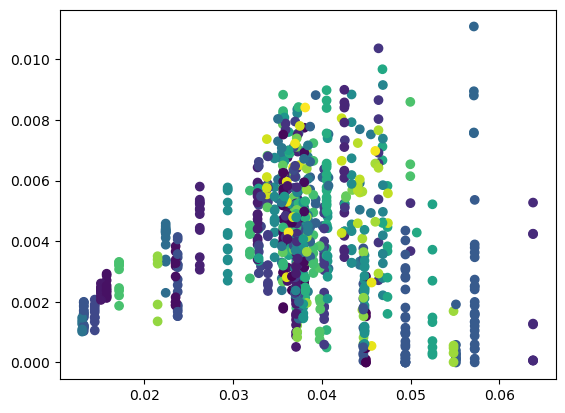

In [85]:
plt.scatter(events_this_catchment['lu_at_peak'], events_this_catchment['fu_at_peak_new'],
          c=events_this_catchment['peak_cell_id'])

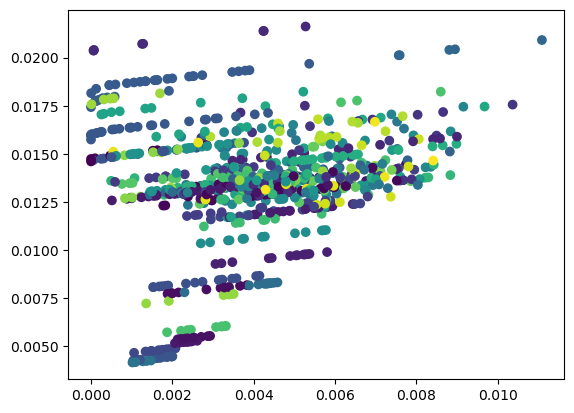

In [86]:
plt.scatter(events_this_catchment['fu_at_peak_new'], events_this_catchment['fu_at_peak_old'],
          c=events_this_catchment["peak_cell_id"])

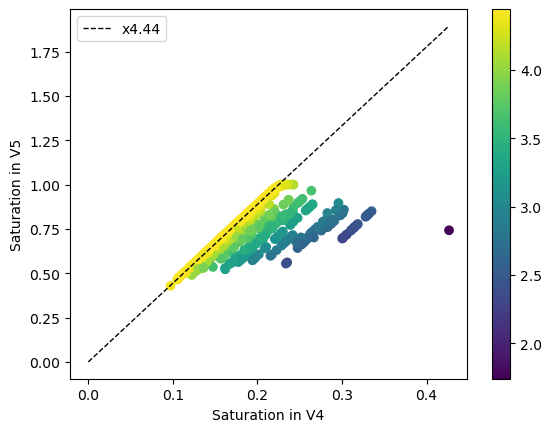

In [33]:
sc = plt.scatter(events_this_catchment['sat_at_peak_old'], events_this_catchment['sat_at_peak_new'], 
            c = events_this_catchment['sat_at_peak_new'] / events_this_catchment['sat_at_peak_old'],)
plt.xlabel('Saturation in V4')
plt.ylabel('Saturation in V5')
plt.colorbar(sc)

# reference line: V5 = 4.44 * V4
x_ref = np.array([0, events_this_catchment['sat_at_peak_old'].max()])
plt.plot(x_ref, 4.44 * x_ref, 'k--', linewidth=1, label='x4.44')
plt.legend()

### Testing characteristics of events where soil moisture ends up over 1

In [33]:
grav_over1 = grav_30m_array[over1_mask]
porosity_over1 = porosity_data[over1_mask]
sat_over1 = vol_sm_raw[over1_mask]

diagnostic = pd.DataFrame({"grav_sm": grav_over1,"porosity": porosity_over1,"vol_sm_raw": sat_over1})
over1_mask = (vol_sm_raw > 1) & np.isfinite(vol_sm_raw)
diagnostic = pd.DataFrame({"grav_sm": grav_30m_array[over1_mask],"porosity": porosity_data[over1_mask],
                           "vol_sm_raw": vol_sm_raw[over1_mask]})
print(diagnostic.sort_values("vol_sm_raw", ascending=False))

          grav_sm  porosity  vol_sm_raw
14661   93.615837     0.385    1.080702
14664   93.615837     0.385    1.080702
14665   93.615837     0.385    1.080702
14998   93.615837     0.385    1.080702
15666   93.615837     0.385    1.080702
...           ...       ...         ...
106347  86.656212     0.385    1.000360
106346  86.656212     0.385    1.000360
106345  86.656212     0.385    1.000360
106344  86.656212     0.385    1.000360
106343  86.656212     0.385    1.000360

[106355 rows x 3 columns]


### Plot to see where saturation is 1 (areas where porosity is 0)

AttributeError: QuadMesh.set() got an unexpected keyword argument 'origin'

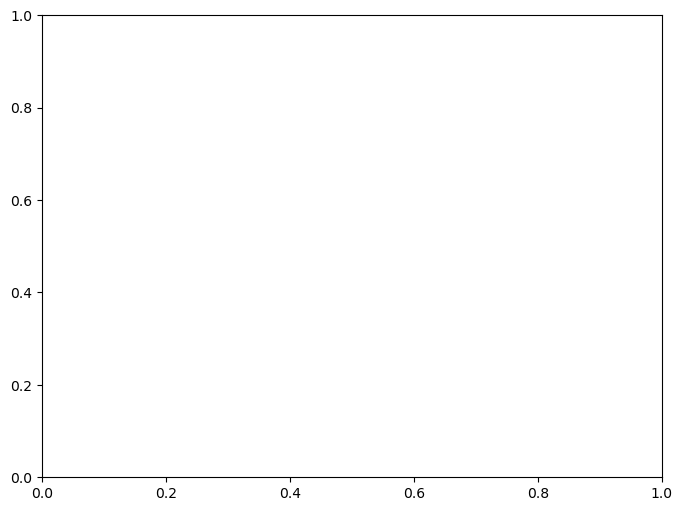

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

plot_data = saturation_5km.copy()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(plot_data, vmin=0, vmax=1, cmap="viridis_r", origin="lower")
fig.colorbar(im, ax=ax, label="Soil saturation")
plt.show()